# Sector reversal: one-month losers need not be twelve-month losers

**Constructed educational scenarios; no measured reversal premium.** The one-month loser basket contains the twelve-month winners in this example. Identical signal histories lead to a +5% gross rebound or a −5% gross continuation result, showing how the result depends on the future hypothesis.

[Chapter narrative](README.md) · [Research collection](../../README.md)

## Goal

Separate the ranking horizon, ranking direction and holding interval. The original `08_sector_rotation_with_reverse_momentum.ipynb` selected twelve-month losers; its prose did not consistently distinguish that rule from momentum. This chapter preserves the annual-loser comparison and explicitly introduces a different, short-horizon reversal hypothesis.

## Setup

Six fictional sectors begin at 100. Month-12 prices specify annual returns, while month-11 prices are chosen to produce different final-month rankings. Constructed month-13 execution prices are shared by two alternative month-14 futures. No external data, historical ETF returns or probabilities are used.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (10, 4.6), 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.18,
    'axes.axisbelow': True, 'figure.dpi': 120,
})
BLUE, GOLD, GRAY = '#245a81', '#bc8431', '#606975'
# All prices are constructed inside this notebook; there are no downloads.

In [2]:
annual_return = pd.Series({
    'Technology': 0.30, 'Financials': 0.15, 'Staples': 0.10,
    'Industrials': 0.05, 'Utilities': -0.10, 'Energy': -0.20,
})
latest_month_return = pd.Series({
    'Technology': -0.08, 'Financials': -0.05, 'Staples': 0.01,
    'Industrials': 0.02, 'Utilities': 0.03, 'Energy': 0.04,
})
sectors = list(annual_return.index)
month12 = 100 * (1 + annual_return)
month11 = month12 / (1 + latest_month_return)
history = pd.DataFrame(
    100 * (month11.to_numpy() / 100)[None, :] ** (np.arange(12)[:, None] / 11),
    columns=sectors, index=pd.Index(range(12), name='Constructed month'),
)
history.loc[12] = month12
display(history.loc[[0, 11, 12]].round(2))

,Technology,Financials,Staples,Industrials,Utilities,Energy
Constructed month,,,,,,
0,100.0,100.00,100.00,100.00,100.00,100.00
11,141.3,121.05,108.91,102.94,87.38,76.92
12,130.0,115.00,110.00,105.00,90.00,80.00


## Steps

### 1. Compare three explicit ranking rules

A one-month loser rule asks about a short move unwinding. A twelve-month loser rule holds long-term laggards. A twelve-month winner rule expresses momentum. These are long-only, two-sector, equal-weight baskets with alphabetical tie resolution; they are not market-neutral factor portfolios.

In [3]:
def rank_weights(path, information_month, lag, buy_losers):
    available = path.loc[:information_month]
    if len(available) < lag + 1 or available.isna().any().any():
        raise ValueError('Insufficient complete history.')
    if (available <= 0).any().any() or not np.isfinite(available.to_numpy()).all():
        raise ValueError('Price levels must be finite and positive.')
    score = available.iloc[-1] / available.iloc[-1 - lag] - 1
    ranked = score.sort_index().sort_values(ascending=buy_losers, kind='stable')
    weights = pd.Series(0.0, index=sectors)
    weights.loc[ranked.head(2).index] = 0.5
    return weights

weights = pd.DataFrame({
    'One-month losers': rank_weights(history, 12, 1, True),
    'Twelve-month losers': rank_weights(history, 12, 12, True),
    'Twelve-month winners': rank_weights(history, 12, 12, False),
})
comparison = pd.DataFrame({'Twelve-month return': annual_return, 'One-month return': latest_month_return}).join(weights)
display(comparison.style.format('{:.1%}'))

,Twelve-month return,One-month return,One-month losers,Twelve-month losers,Twelve-month winners
Technology,30.0%,-8.0%,50.0%,0.0%,50.0%
Financials,15.0%,-5.0%,50.0%,0.0%,50.0%
Staples,10.0%,1.0%,0.0%,0.0%,0.0%
Industrials,5.0%,2.0%,0.0%,0.0%,0.0%
Utilities,-10.0%,3.0%,0.0%,50.0%,0.0%
Energy,-20.0%,4.0%,0.0%,50.0%,0.0%


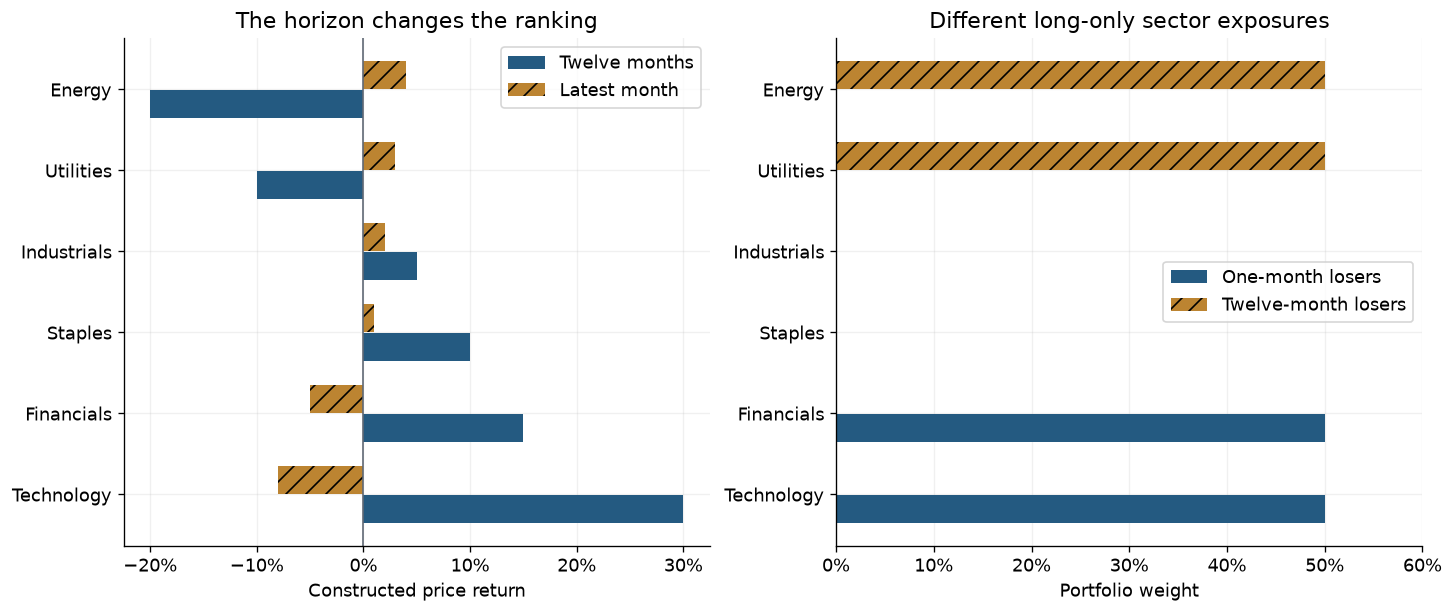

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
y = np.arange(len(sectors))
axes[0].barh(y - 0.18, annual_return, 0.34, color=BLUE, label='Twelve months')
axes[0].barh(y + 0.18, latest_month_return, 0.34, color=GOLD, hatch='//', label='Latest month')
axes[0].set(yticks=y, yticklabels=sectors, xlabel='Constructed price return', title='The horizon changes the ranking')
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].axvline(0, color=GRAY, linewidth=1)
axes[0].legend()
axes[1].barh(y - 0.18, weights['One-month losers'], 0.34, color=BLUE, label='One-month losers')
axes[1].barh(y + 0.18, weights['Twelve-month losers'], 0.34, color=GOLD, hatch='//', label='Twelve-month losers')
axes[1].set(yticks=y, yticklabels=sectors, xlim=(0, 0.6), xlabel='Portfolio weight', title='Different long-only sector exposures')
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend(loc='center right')
plt.show()

Technology and Financials were strong over twelve months but weak in the latest month. A short-term reversal position can therefore coincide with a longer-term momentum position. Calling both annual and monthly loser rules “reverse momentum” hides this distinction.

### 2. Hold the information set fixed and change only the future

A trade lag separates the month-12 signal from month-13 execution. The pre-execution move is not a held return. The rebound and continuation futures then disagree about the month-13-to-14 return. Neither scenario is assigned a probability.

In [5]:
signal_month, execution_month, exit_month = 12, 13, 14
fill_gap = pd.Series([-0.04, -0.02, 0.01, 0.0, 0.02, 0.05], index=sectors)
execution_price = history.loc[12] * (1 + fill_gap)
rebound_return = pd.Series([0.06, 0.04, 0.0, 0.0, -0.02, -0.03], index=sectors)
future_returns = {'Rebound': rebound_return, 'Continuation': -rebound_return}
rate = 0.001  # 10 basis points on entry and exit notional.
rows, extended_paths = [], {}
for scenario, return_vector in future_returns.items():
    terminal_price = execution_price * (1 + return_vector)
    extended = history.copy()
    extended.loc[execution_month] = execution_price
    extended.loc[exit_month] = terminal_price
    extended_paths[scenario] = extended
    for strategy, target in weights.items():
        initial_cash = 100.0
        invested_notional = initial_cash / (1 + rate)
        units = target * invested_notional / execution_price
        sale_notional = float(units @ terminal_price)
        exit_fee = rate * sale_notional
        wealth = sale_notional - exit_fee
        gross_return = float(target @ return_vector)
        rows.append({
            'Scenario': scenario, 'Strategy': strategy,
            'Gross return': gross_return, 'Net return': wealth / initial_cash - 1,
            'Entry fee': invested_notional * rate, 'Exit fee': exit_fee,
            'Terminal wealth': wealth,
        })
results = pd.DataFrame(rows).set_index(['Scenario', 'Strategy'])
display(results.round(6))

Gross return  Net return  Entry fee  \
Scenario     Strategy                                                    
Rebound      One-month losers             0.050    0.047902     0.0999   
             Twelve-month losers         -0.025   -0.026948     0.0999   
             Twelve-month winners         0.050    0.047902     0.0999   
Continuation One-month losers            -0.050   -0.051898     0.0999   
             Twelve-month losers          0.025    0.022952     0.0999   
             Twelve-month winners        -0.050   -0.051898     0.0999   

                                   Exit fee  Terminal wealth  
Scenario     Strategy                                         
Rebound      One-month losers      0.104895       104.790210  
             Twelve-month losers   0.097403        97.305195  
             Twelve-month winners  0.104895       104.790210  
Continuation One-month losers      0.094905        94.810190  
             Twelve-month losers   0.102398       102.295205  
             Twelve-month winners  0.094905        94.810190

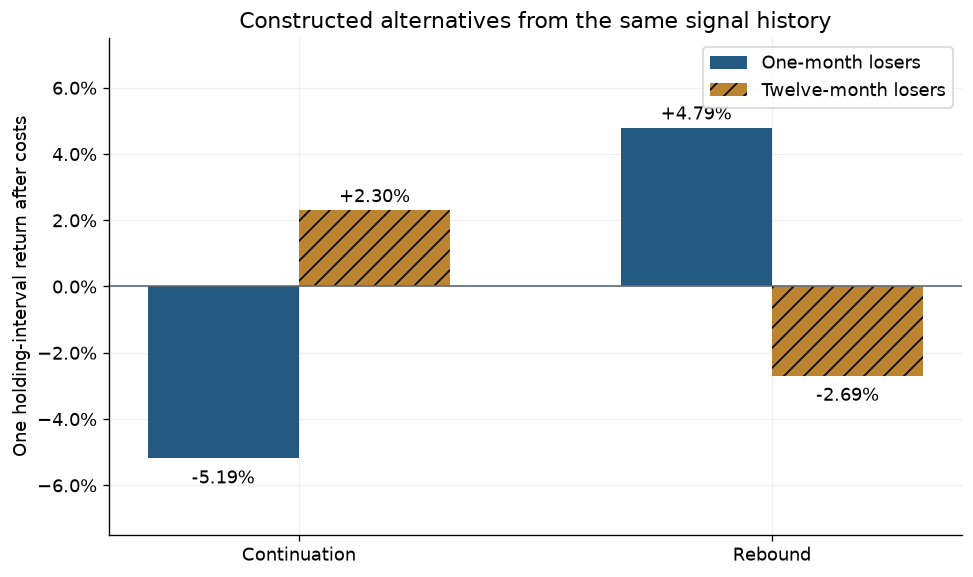

In [6]:
shown = results['Net return'].unstack('Strategy')[['One-month losers', 'Twelve-month losers']]
x = np.arange(len(shown))
fig, ax = plt.subplots(figsize=(8, 4.7), layout='constrained')
for j, name in enumerate(shown):
    bars = ax.bar(x + (j - 0.5) * 0.32, shown[name], 0.32,
                  color=[BLUE, GOLD][j], label=name, hatch=['', '//'][j])
    for bar, value in zip(bars, shown[name]):
        ax.annotate(f'{value:+.2%}', (bar.get_x() + bar.get_width()/2, value),
                    xytext=(0, 5 if value >= 0 else -15), textcoords='offset points', ha='center')
ax.axhline(0, color=GRAY, linewidth=1)
ax.set(xticks=x, xticklabels=shown.index, ylim=(-0.075, 0.075),
       ylabel='One holding-interval return after costs',
       title='Constructed alternatives from the same signal history')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(loc='upper right')
plt.show()

The short-horizon basket earns +5% gross in the rebound and −5% gross in continuation. Costs lower both net results. The annual-loser basket has the opposite scenario ordering. These are controlled arithmetic cases, not estimates of the frequency or size of real reversals.

## Checks

In [7]:
assert set(weights.index[weights['One-month losers'] > 0]) == {'Technology', 'Financials'}
assert set(weights.index[weights['Twelve-month losers'] > 0]) == {'Utilities', 'Energy'}
np.testing.assert_allclose(weights['One-month losers'], weights['Twelve-month winners'])
np.testing.assert_allclose(weights.sum(), 1)
assert (weights >= 0).all().all()
np.testing.assert_allclose(results.loc[('Rebound', 'One-month losers'), 'Gross return'], 0.05)
np.testing.assert_allclose(results.loc[('Continuation', 'One-month losers'), 'Gross return'], -0.05)
independent_wealth = 100 * (1 + results['Gross return']) * (1 - rate) / (1 + rate)
np.testing.assert_allclose(results['Terminal wealth'], independent_wealth)
assert (results['Net return'] < results['Gross return']).all()
for future in extended_paths.values():
    pd.testing.assert_series_equal(rank_weights(future, signal_month, 1, True),
                                   weights['One-month losers'], check_names=False)
assert signal_month < execution_month < exit_month
display(pd.DataFrame({'Information close': [signal_month], 'Execution close': [execution_month],
                      'First earned return ends': [exit_month]}))
print('Passed: horizon-specific holdings, budgets, independent cash flows, costs and future invariance.')

,Information close,Execution close,First earned return ends
0,12,13,14


Passed: horizon-specific holdings, budgets, independent cash flows, costs and future invariance.


## Next steps

A historical design should distinguish a one-month signal from a one-month holding period, fix the execution calendar, and compare horizons without choosing them on the evaluation sample. Liquidity, industry exposures, market beta and persistent distress can all explain apparent loser returns. The annual-loser rule remains visible as the original topic; the short-horizon exercise is a separate, stated research hypothesis.

[Return to sector momentum](../06-sector-momentum/README.md) or [the research collection](../../README.md).